In [ ]:
import os, re, json, glob, subprocess, pathlib, difflib

try:
    from google.colab import userdata
    OPENAI_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    OPENAI_KEY = os.environ.get("OPENAI_API_KEY", "")
OPENAI_KEY = OPENAI_KEY or "sk-PASTE-YOUR-KEY-HERE"
assert OPENAI_KEY.startswith("sk-"), "Set a real OpenAI key (Colab Secrets -> OPENAI_API_KEY)."

OPTIMIZER_MODEL = "gpt-4o"
TARGET_MODEL    = "gpt-4o-mini"
RUN  = "outputs/searchqa_adv"
LIMIT = 24
RUN_KNOBS = dict(num_epochs=2, batch_size=8, minibatch=4, merge_batch=4,
                 workers=2, lr=4, lr_sched="cosine", limit=LIMIT)

if not pathlib.Path("/content/SkillOpt/scripts/train.py").exists():
    subprocess.run("git clone --depth 1 https://github.com/microsoft/SkillOpt.git",
                   shell=True, cwd="/content")
    subprocess.run('pip -q install -e . && pip -q install "openai>=1.0" pandas matplotlib',
                   shell=True, cwd="/content/SkillOpt")
os.chdir("/content/SkillOpt")

os.environ["AZURE_OPENAI_ENDPOINT"]  = "https://api.openai.com/v1"
os.environ["AZURE_OPENAI_API_KEY"]   = OPENAI_KEY
os.environ["AZURE_OPENAI_AUTH_MODE"] = "openai_compatible"

SPLIT = "data/searchqa_id_split"
CFG   = "configs/searchqa/default.yaml"
COMMON = ["--azure_openai_endpoint","https://api.openai.com/v1",
          "--cfg-options","model.backend=azure_openai",
          "model.azure_openai_auth_mode=openai_compatible"]

In [ ]:
def run_cli(args, tag):
    print("\n" + "#"*80 + f"\n# {tag}\n# $ " + " ".join(args) + "\n" + "#"*80)
    p = subprocess.Popen(args, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    buf = []
    for line in p.stdout:
        print(line, end=""); buf.append(line)
    p.wait(); return "".join(buf)

def parse_acc(txt):
    m = re.search(r"Results:\s*hard=([\d.]+)\s+soft=([\d.]+)", txt)
    if m: return {"hard": float(m.group(1)), "soft": float(m.group(2))}
    g = re.findall(r"hard=([\d.]+)", txt)
    return {"hard": float(g[-1]), "soft": None} if g else None

seed = "skillopt/envs/searchqa/skills/initial.md"
if not pathlib.Path(seed).exists():
    seed = "baseline_skill.md"; pathlib.Path(seed).write_text("You answer questions from the given context.\n")
base_out = run_cli(["python","scripts/eval_only.py","--config",CFG,
                    "--skill",seed,"--split","valid_unseen","--split_dir",SPLIT,
                    "--target_model",TARGET_MODEL,*COMMON,
                    "env.workers=1",f"env.limit={LIMIT}"],
                   "BASELINE EVAL (env seed skill, no training)")
base = parse_acc(base_out)

In [ ]:
k = RUN_KNOBS
train_out = run_cli(["python","scripts/train.py","--config",CFG,"--split_dir",SPLIT,
    "--optimizer_model",OPTIMIZER_MODEL,"--target_model",TARGET_MODEL,"--out_root",RUN,
    *COMMON,
    "train.train_size=0",
    f"train.num_epochs={k['num_epochs']}", f"train.batch_size={k['batch_size']}",
    f"gradient.minibatch_size={k['minibatch']}", f"gradient.merge_batch_size={k['merge_batch']}",
    f"gradient.analyst_workers={k['workers']}",
    f"optimizer.learning_rate={k['lr']}", f"optimizer.lr_scheduler={k['lr_sched']}",
    "optimizer.use_slow_update=true", "optimizer.use_meta_skill=true",
    f"env.workers={k['workers']}", f"env.limit={k['limit']}"],
    "TRAIN (rollout->reflect->aggregate->select->update->gate; slow-update + meta-skill)")

import pandas as pd, matplotlib.pyplot as plt
hist = json.loads(pathlib.Path(f"{RUN}/history.json").read_text())
df = pd.json_normalize(hist)
print("\nhistory.json columns:", list(df.columns))
def col(*cands):
    for c in cands:
        for actual in df.columns:
            if c in actual.lower(): return actual
    return None
c_step = col("step")
x = df[c_step] if c_step else range(len(df))
c_tr, c_va = col("train_acc","train_hard","train"), col("val_acc","val_hard","valid","val")
c_lr, c_tok = col("edit_budget","lr","learning_rate","budget"), col("token","cost")
fig, ax = plt.subplots(1, 3, figsize=(16,4))
if c_tr: ax[0].plot(x, df[c_tr], "o-", label="train acc")
if c_va: ax[0].plot(x, df[c_va], "s-", label="val acc (gate)")
if base and base["hard"] is not None: ax[0].axhline(base["hard"], ls="--", c="grey", label="baseline (seed)")
ax[0].set_title("Skill accuracy over steps"); ax[0].set_xlabel("step"); ax[0].legend(); ax[0].grid(alpha=.3)
if c_lr: ax[1].plot(x, df[c_lr], "d-", c="purple")
ax[1].set_title("Edit-budget / LR schedule (cosine)"); ax[1].set_xlabel("step"); ax[1].grid(alpha=.3)
if c_tok: ax[2].plot(x, pd.to_numeric(df[c_tok],errors="coerce").cumsum(), c="darkorange")
ax[2].set_title("Cumulative token usage"); ax[2].set_xlabel("step"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{RUN}/training_dashboard.png", dpi=120); plt.show()

In [ ]:
snaps = sorted(glob.glob(f"{RUN}/skills/skill_v*.md"))
best  = pathlib.Path(f"{RUN}/best_skill.md").read_text()
print("\n" + "="*80 + f"\nSKILL EVOLUTION: {len(snaps)} snapshots; diff v0 -> best_skill\n" + "="*80)
if snaps:
    diff = difflib.unified_diff(pathlib.Path(snaps[0]).read_text().splitlines(),
                                best.splitlines(), snaps[0].split('/')[-1], "best_skill.md", lineterm="")
    print("\n".join(list(diff)[:120]) or "(no textual diff captured)")
prot = re.search(r"(SLOW_UPDATE.*?)$", best, re.S)
print("\n--- protected SLOW_UPDATE block ---\n",
      prot.group(1)[:1500] if prot else "(none — appears after an epoch boundary)")

patch = (sorted(glob.glob(f"{RUN}/steps/step_*/patches/*.json")) or [None])[0]
analy = (sorted(glob.glob(f"{RUN}/steps/step_*/analysis/*")) or [None])[0]
print("\n" + "="*80 + "\nTEXTUAL GRADIENT — one aggregated patch (clipped to edit budget):\n" + "="*80)
print(pathlib.Path(patch).read_text()[:1500] if patch else "(no patch files)")
print("\n--- one raw Reflect-stage analysis ---\n",
      pathlib.Path(analy).read_text()[:1000] if analy else "(no analysis files)")

for name in ("slow_update", "meta_skill"):
    files = sorted(glob.glob(f"{RUN}/{name}/epoch_*/*"))
    print(f"\n[{name}] {len(files)} artifact(s):", [pathlib.Path(f).name for f in files[:6]])


################################################################################
# BASELINE EVAL (env seed skill, no training)
# $ python scripts/eval_only.py --config configs/searchqa/default.yaml --skill skillopt/envs/searchqa/skills/initial.md --split valid_unseen --split_dir data/searchqa_id_split --target_model gpt-4o-mini --azure_openai_endpoint https://api.openai.com/v1 --cfg-options model.backend=azure_openai model.azure_openai_auth_mode=openai_compatible env.workers=1 env.limit=24
################################################################################
  [skill] /content/SkillOpt/skillopt/envs/searchqa/skills/initial.md (104 chars)
  [SearchQADataLoader] train=24 val=24 test=24  (from data/searchqa_id_split)

  [eval] split=valid_unseen  items=24
  [eval] out_root=/content/SkillOpt/outputs/eval_searchqa_gpt-4o-mini_20260606_115001
    [rollout] 1/24 (acc=0.000) id=5093b6d997674d25be29a4c94fcd5185 hard=0
    [rollout] 2/24 (acc=0.000) id=99dc9de2fd094b8e9de41a9040081c1

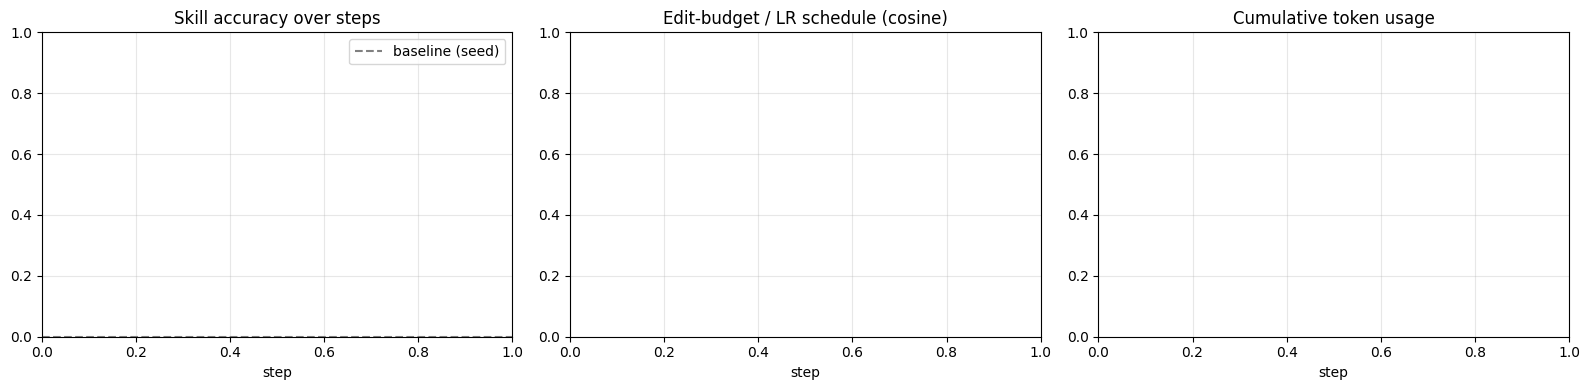


SKILL EVOLUTION: 7 snapshots; diff v0 -> best_skill
(no textual diff captured)

--- protected SLOW_UPDATE block ---
 (none — appears after an epoch boundary)

TEXTUAL GRADIENT — one aggregated patch (clipped to edit budget):
(no patch files)

--- one raw Reflect-stage analysis ---
 (no analysis files)

[slow_update] 5 artifact(s): ['slow_result.json', 'comparison_pairs.json', 'rollout_curr', 'rollout_prev', 'slow_result.json']

[meta_skill] 2 artifact(s): ['meta_skill_result.json', 'meta_skill_result.json']

################################################################################
# FINAL TEST EVAL (best_skill)
# $ python scripts/eval_only.py --config configs/searchqa/default.yaml --skill outputs/searchqa_adv/best_skill.md --split valid_unseen --split_dir data/searchqa_id_split --target_model gpt-4o-mini --azure_openai_endpoint https://api.openai.com/v1 --cfg-options model.backend=azure_openai model.azure_openai_auth_mode=openai_compatible env.workers=1 env.limit=24
###########

In [2]:
best_out = run_cli(["python","scripts/eval_only.py","--config",CFG,
                    "--skill",f"{RUN}/best_skill.md","--split","valid_unseen","--split_dir",SPLIT,
                    "--target_model",TARGET_MODEL,*COMMON,"env.workers=1",f"env.limit={LIMIT}"],
                   "FINAL TEST EVAL (best_skill)")
trained = parse_acc(best_out)
print("\n" + "="*80 + "\nRESULT (hard = exact match, the gated metric)\n" + "="*80)
print(f"baseline seed skill : {base}")
print(f"trained best_skill  : {trained}")
if base and trained:
    print(f"hard-match lift     : {trained['hard'] - base['hard']:+.4f}")
print(f"\nDeployable artifact: {RUN}/best_skill.md  ({len(best)} chars)")